# Hoja de Trabajo 2

## Integrantes

| Nombre                            | Carnet | Usuario Git |
| --------------------------------- | ------ | ----------- |
| Edwin Jose Gabriel De Leon Garcia | 22809  | EJGDLG      |
| Gustavo Adolfo Cruz Bardales      | 22779  | G2309       |
| Josué Emanuel Say Garcia          | 22801  | JosueSay    |
| Mathew Alexander Cordero Aquino   | 22982  | donmatthiuz |


## Repositorio

[Link al Repositorio](https://github.com/donmatthiuz/RL/tree/hdt2)


## Task 1

Responda las siguientes preguntas de forma clara, concisa y argumentada. No basta con definir, se espera que usted conecte el concepto con sus implicaciones prácticas o estratégicas.

### Inciso 1

Elijan un sistema real que pueda modelarse como un k-armed bandit. Su modelado debe incluir:

**Sistema elegido:** selección de la miniatura de portada que se muestra para una serie en una plataforma de streaming, con el fin de maximizar los clics de los usuarios.

El sistema recibe un catálogo de portadas producidas para una misma serie y debe decidir cuál desplegar. Cada vez que un usuario ve la portada, el sistema observa si genera clic o no, y con esa señal ajusta su preferencia por una u otra imagen. El reto es equilibrar entre repetir la portada que hasta ahora convierte mejor y probar otras para descubrir si alguna convierte aún más.

#### Inciso a

Definición formal de los **k** brazos: qué representa cada acción y por qué el conjunto de acciones es finito y discreto en este dominio.

**Respuesta:**

En este sistema cada brazo representa una de las miniaturas de portada disponibles para la serie. El conjunto de acciones es

$$
\mathcal{A} = {a_1, a_2, \dots, a_k}
$$

donde cada acción $a_i$ significa "mostrar la miniatura $i$ como portada de la serie". El número de brazos $k$ corresponde a la cantidad de portadas creadas para esa serie. Elegir un brazo $A_t = a_i$ es la decisión de qué imagen desplegar, y a cada brazo le corresponde un valor real desconocido $q_*(a_i) = \mathbb{E}[R_t \mid A_t = a_i]$, la tasa de clic esperada de esa portada, que el agente no conoce y solo puede estimar mediante $Q_t(a_i)$.

El conjunto de acciones es finito porque las miniaturas son un catálogo fijo creado de antemano por el equipo de diseño y no se generan portadas nuevas durante la operación.

El conjunto es discreto porque las acciones son mutuamente excluyentes y sin puntos intermedios, se muestra la portada $a_2$ o la $a_5$, pero no existe una "portada 2.5" ni una mezcla continua entre dos miniaturas. Cada brazo es una categoría separada e identificable, sin una noción de cercanía entre ellas, lo cual encaja con el supuesto del k-armed bandit de un espacio de acciones enumerable donde cada acción se estima por separado.

Al ser $k$ pequeño, la exploración aleatoria del epsilon-greedy sigue siendo viable, y permite mantener una estimación $Q_t(a_i)$ por brazo actualizada de forma independiente mediante $Q_{n+1} = Q_n + \alpha(R_n - Q_n)$.

#### Inciso b

Diseño justificado de la función de recompensa: qué se mide, cómo se mide, y qué supuestos distribucionales son razonables para ese dominio. Si la recompensa no es gaussiana, arguméntenlo.

**Respuesta:**

Qué se mide. La recompensa mide la interacción del usuario con la portada mostrada, que es la señal directamente ligada al objetivo del sistema: maximizar los clics:

$$
R_t = \begin{cases} 1 & \text{si el usuario hace clic en la portada mostrada} \ 0 & \text{en caso contrario} \end{cases}
$$

Se elige el clic porque es la señal más inmediata, atribuible sin ambigüedad a la miniatura elegida en ese instante.

Cada vez que se muestra la portada $a_i$ a un usuario (una impresión) se registra un único valor $R_t \in {0, 1}$. El valor verdadero del brazo, $q_*(a_i) = \mathbb{E}[R_t \mid A_t = a_i]$, es entonces la tasa de clic (CTR) esperada de esa miniatura "la probabilidad de que una impresión de $a_i$ termine en clic". El agente lo estima con el promedio de las recompensas observadas:

$$
Q_t(a_i) = \frac{\text{clics de } a_i}{\text{impresiones de } a_i}
$$

Esta estimación se puede mantener de forma incremental con $Q_{n+1} = Q_n + \alpha(R_n - Q_n)$, sin guardar el historial completo, lo cual es indispensable en un sistema con millones de impresiones.

Supuesto distribucional: la recompensa NO es gaussiana. Como $R_t$ solo puede valer 0 o 1, no puede modelarse con una distribución normal, que es continua y con soporte en toda la recta real.

- Soporte discreto y acotado. La observación vive en ${0, 1}$.
- Asimetría en CTR bajos. Las tasas de clic reales suelen ser pequeñas (del orden de unos pocos por ciento), lo que produce una distribución muy sesgada hacia el 0; la simetría de la gaussiana no captura ese comportamiento.

Tres pasos del bandido:

```mermaid
flowchart TD
    A[Inicio de impresion t] --> B[Agente elige un brazo A_t=a_i<br/>segun Q_t con exploracion-explotacion]
    B --> C[Se muestra la miniatura a_i al usuario]
    C --> D{El usuario<br/>hace clic?}
    D -->|Si| E[Recompensa R_t=1]
    D -->|No| F[Recompensa R_t=0]
    E --> G[Actualizacion incremental<br/>Q_n+1 = Q_n + alpha R_n - Q_n]
    F --> G
    G --> H[Estimacion actualizada del CTR de a_i]
    H --> A
```

#### Inciso c

Análisis de estacionariedad: ¿los valores verdaderos (q_*(a)) cambian con el tiempo en este sistema? ¿En qué escala temporal? ¿Qué implicaciones tiene eso para el algoritmo de actualización?

**Respuesta:**

¿Cambian los $q_*(a)$ con el tiempo?

Sí. En este sistema el valor verdadero de cada brazo "la tasa de clic esperada $q_*(a_i)$ de la miniatura $i$" no es constante, por lo que el sistema es no estacionario. La atracción de una portada depende de factores que evolucionan: las tendencias culturales, la novedad de la serie, la composición de la audiencia que llega a esa pantalla y hasta la estación del año. Una miniatura que hoy convierte al 8 % puede caer al 3 % meses después sin que la imagen haya cambiado, simplemente porque el contexto que la hacía atractiva se movió. Esto rompe el supuesto estacionario que asume que "el valor de una acción se mantiene igual durante todo el periodo".

¿En qué escala temporal cambian? Hay que distinguir varias escalas, porque cada una exige una respuesta distinta:

- Corto plazo (horas / días): oscilaciones por hora del día o día de la semana (no es igual la audiencia de un lunes en la mañana que la de un viernes en la noche). Es una variación de alta frecuencia pero de amplitud moderada.
- Mediano plazo (semanas / meses): desgaste por novedad. Una portada recién estrenada capta la atención por ser nueva; conforme los usuarios la ven repetidamente, su CTR decae. Es la escala más relevante para el diseño del algoritmo.
- Largo plazo (temporadas / años): cambios en tendencias, en el catálogo competidor o en la base de usuarios, que pueden redefinir por completo cuál portada es la mejor.

Implicaciones para el algoritmo de actualización. El promedio muestral es inadecuado aquí. Como da el mismo peso a toda observación histórica, una impresión de hace un año pesa igual que la de hoy, lo que hace que el agente reaccione con lentitud o directamente no reaccione cuando el mejor brazo cambia. La consecuencia es que quedaría anclado a una portada que fue óptima en el pasado pero ya no lo es.

La solución que corresponde a este dominio es usar un paso constante $\alpha \in (0, 1]$ en lugar de $\alpha = 1/n$:

$$
Q_{n+1} = Q_n + \alpha(R_n - Q_n)
$$

Con $\alpha$ constante, la estimación se convierte en un promedio de recencia ponderada exponencialmente:

$$
Q_{n+1} = (1-\alpha)^n Q_0 + \sum_{i=1}^{n} \alpha (1-\alpha)^{n-i} R_i
$$

donde las impresiones recientes pesan más y las antiguas decaen exponencialmente. Esto le da al agente una "memoria corta" que le permite seguir el CTR real conforme se mueve.

La elección de $\alpha$ implica un compromiso ligado a la escala temporal:

- Un $\alpha$ grande (memoria corta) rastrea cambios rápidos pero introduce más varianza, porque reacciona en exceso al ruido de cada impresión.
- Un $\alpha$ pequeño (memoria larga) estima con más estabilidad pero se rezaga ante cambios reales.

Para este sistema, $\alpha$ debe calibrarse a la escala de mediano plazo —el desgaste por novedad de semanas/meses—, que es la dinámica dominante y accionable, absorbiendo el ruido de corto plazo con suficientes impresiones sin quedar rezagado ante las tendencias de largo plazo.

La no estacionariedad tiene una segunda implicación: dado que el mejor brazo puede cambiar, el agente nunca puede dejar de explorar del todo. Un epsilon-greedy con $\varepsilon$ decayendo a cero, o un greedy puro, se congelaría en la portada antes óptima.

#### Inciso d

Identificación de restricciones de exploración: ¿hay costos económicos, de seguridad o regulatorios que limiten cuánto puede explorar el sistema?

**Respuesta:**

Cada impresión gastada en una miniatura peor tiene un costo real. Ese costo se cuantifica con el regret acumulado $L_T = \sum_a \Delta_a N_T(a)$: cada vez que se muestra una portada subóptima se suma un gap $\Delta_a = q_*(a^) - q_(a)$ de clics perdidos.

Costos económicos. Son los más directos. Cada impresión asignada a una portada inferior significa clics y por tanto reproducciones, retención y en última instancia ingresos por suscripción o publicidad que no ocurrieron. En un sistema con millones de impresiones diarias, incluso una fracción pequeña de exploración excesiva se traduce en una pérdida agregada considerable. Esto acota $\varepsilon$ a valores bajos ($[0.01, 0.1]$) y hace preferible una exploración dirigida como UCB, que no malgasta impresiones en brazos ya bien estimados, sobre la exploración uniforme del epsilon-greedy que puede volver a probar una portada visitada cien veces.

Costos de experiencia de usuario. Explorar demasiado degrada la percepción del producto. Mostrar repetidamente portadas poco atractivas o inconsistentes hace que la interfaz se sienta errática, y a diferencia del regret de clics, este daño puede afectar la retención a largo plazo del usuario, un costo que el modelo de bandido puro ni siquiera captura porque no tiene estados.

La exploración debe ser acotada mediante un $\varepsilon$ bajo o un $c$ moderado en UCB; dirigida hacia los brazos genuinamente inciertos para minimizar el regret; y segura porque el catálogo de brazos ya está filtrado antes de que el algoritmo actúe. El objetivo es que aprenda rápido cuál portada conviene y deje de pagar el costo de explorar más de lo necesario.

### Inciso 2

Con base en el análisis anterior, propongan y justifiquen:

#### Inciso a

La estrategia de selección de acción más apropiada para su dominio, con el valor concreto del hiperparámetro relevante ((\varepsilon) o (c)) y la justificación de ese valor.

**Respuesta:**

La estrategia recomendada para este sistema es Upper Confidence Bound, con constante de exploración **$c = 1$**.Esto, ya que como se explicaba en el inciso 1.d, la restricción económica exige minimizar el regret por impresión, y la exploración uniforme del epsilon-greedy desperdicia impresiones al volver a probar portadas ya bien estimadas con la misma probabilidad que a las inciertas. Pero UCB, dirige la exploración solo hacia los brazos con más incertidumbre, mediante la regla:

$$
A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right]
$$

El término $\sqrt{\ln t / N_t(a)}$ funciona como un bono de incertidumbre que decrece conforme una portada acumula impresiones $N_t(a)$ las miniaturas que ya están bien medidas dejan de explorarse y el algoritmo gasta la exploración solo en las que todavía son inciertas.

Luego, elegimos **$c = 1$** porque un $c$ más alto (por ejemplo 2) infla demasiado el bono y termina reexplorando portadas ya medidas y uno más bajo (por ejemplo 0.5) explora menos de lo necesario para seguir el desgaste por novedad. Con $c = 1$ quedamos en el medio, y de ahí lo ajustaremos empíricamente en el análisis de sensibilidad.

Descartamos greedy puro y epsilon-greedy con $\varepsilon$ decayendo a cero por lo mismo de que si el algoritmo deja de explorar, se queda pegado a la portada que era óptima antes cuando el CTR cambie. Un epsilon-greedy con $\varepsilon$ fijo bajo (~0.05) sí sería una alternativa viable, pero UCB con $c=1$ le gana en regret esperado bajo estas condiciones


#### Inciso b

La regla de actualización de estimaciones (paso variable o constante) con justificación ligada al análisis de estacionariedad.

**Respuesta:**

La regla de actualización es la incremental con paso constante $\alpha = 0.05$:

$$
Q_{n+1}(a) = Q_n(a) + \alpha \left[ R_n - Q_n(a) \right]
$$

La justificación se apoya directamente en el análisis de estacionariedad del inciso 1.c. Se descartó el promedio muestral ($\alpha = 1/n$) porque asigna el mismo peso a toda observación histórica, y en un sistema donde el CTR se desgasta por novedad en escala de semanas a meses eso implica que una impresión de hace un año pesaría igual que la de hoy.

Si dejamos el valor de $\alpha$ fijo, la fórmula se convierte en un promedio donde los datos más recientes tienen más peso:

$$
Q_{n+1} = (1-\alpha)^n Q_0 + \sum_{i=1}^{n} \alpha (1-\alpha)^{n-i} R_i
$$

lo cual le da al agente la "memoria corta" necesaria para seguir el CTR real conforme se mueve.

El valor $\alpha = 0.05$ se elige para calibrar al agente contra la escala de mediano plazo (semanas/meses) identificada anteriormente como la dinámica dominante. Con ese paso, el tiempo característico de decaimiento del peso de una observación es del orden de $1/\alpha = 20$ impresiones suficiente para absorber el ruido de una recompensa Bernoulli individual pero lo bastante ágil para reflejar un cambio real en el CTR de un brazo. Un $\alpha$ mayor  reaccionaría demasiado al ruido de cada impresión y uno menor  reaccionaría con lentitud ante el desgaste por novedad.


#### Inciso c

Un ejemplo numérico con al menos seis observaciones que ilustre cómo evoluciona (Q_t(a)) para dos acciones distintas bajo la regla elegida, mostrando cómo la estimación converge o se adapta.

**Respuesta:**

Simulamos seis impresiones para dos portadas ($a_1$ y $a_2$) usando $\alpha = 0.05$ y una estimación inicial $Q_0 = 0.05$. Las respuestas de los usuarios fueron:

* **$a_1$:** $\{1, 0, 0, 1, 0, 0\}$ (2 clics de 6 impresiones $\rightarrow$ 33% CTR)
* **$a_2$:** $\{1, 1, 1, 1, 0, 1\}$ (5 clics de 6 impresiones $\rightarrow$ 83% CTR)

Calculando paso a paso con la fórmula $Q_{n+1} = Q_n + \alpha(R_n - Q_n)$:

| $t$ | $R_t(a_1)$ | $Q_t(a_1)$ | $R_t(a_2)$ | $Q_t(a_2)$ |
| --- | --- | --- | --- | --- |
| 0 | — | 0.05000 | — | 0.05000 |
| 1 | 1 | 0.09750 | 1 | 0.09750 |
| 2 | 0 | 0.09262 | 1 | 0.14263 |
| 3 | 0 | 0.08799 | 1 | 0.18549 |
| 4 | 1 | 0.13359 | 1 | 0.22622 |
| 5 | 0 | 0.12691 | 0 | 0.21491 |
| 6 | 0 | 0.12057 | 1 | 0.25416 |

De lo que podemos concluir que:

* Aunque ambas empiezan igual, tras solo seis pasos la estimación de $a_2$ ($0.254$) ya duplica a la de $a_1$ ($0.121$), adaptándose bien a la diferencia de clics reales.
*  En $t=5$, el único fallo de $a_2$ apenas baja su estimación ($0.226 \to 0.215$). Esto es gracias a que el $\alpha = 0.05$ evita que un solo evento aislado (un "no clic") arruine todo el historial.
*  Seis pasos no bastan para "congelar" un valor definitivo (y con un $\alpha$ constante el algoritmo nunca lo hace). Esto es ideal para entornos dinámicos: el agente no se queda estancado y, si las preferencias de los usuarios cambian mañana, se adaptará al nuevo CTR sin problemas.

## Task 2

Realice y responda:

### Inciso 1

Implementen en Python un simulador de k-armed bandit con las tres estrategias vistas en clase: greedy puro, epsilon-greedy y UCB1. Su implementación debe incluir:

#### Inciso a

Una clase `KArmedBandit` con soporte para modo estacionario y no estacionario. En modo no estacionario, los valores (q_*(a)) deben perturbarse cada cierto número de pasos configurable.

#### Inciso b

Una clase por cada estrategia con métodos `select_action` y `update`, implementando la regla incremental con soporte para paso variable y paso constante.

#### Inciso c

Un loop de experimento que corra al menos **500 episodios independientes de 1000 pasos**, calculando recompensa promedio por paso y **regret** acumulado.

#### Inciso d

Cuatro gráficas: recompensa promedio y regret acumulado en el entorno estacionario, y las mismas dos métricas en el entorno no estacionario.

### Resultado

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/resultados_estacionario.png'

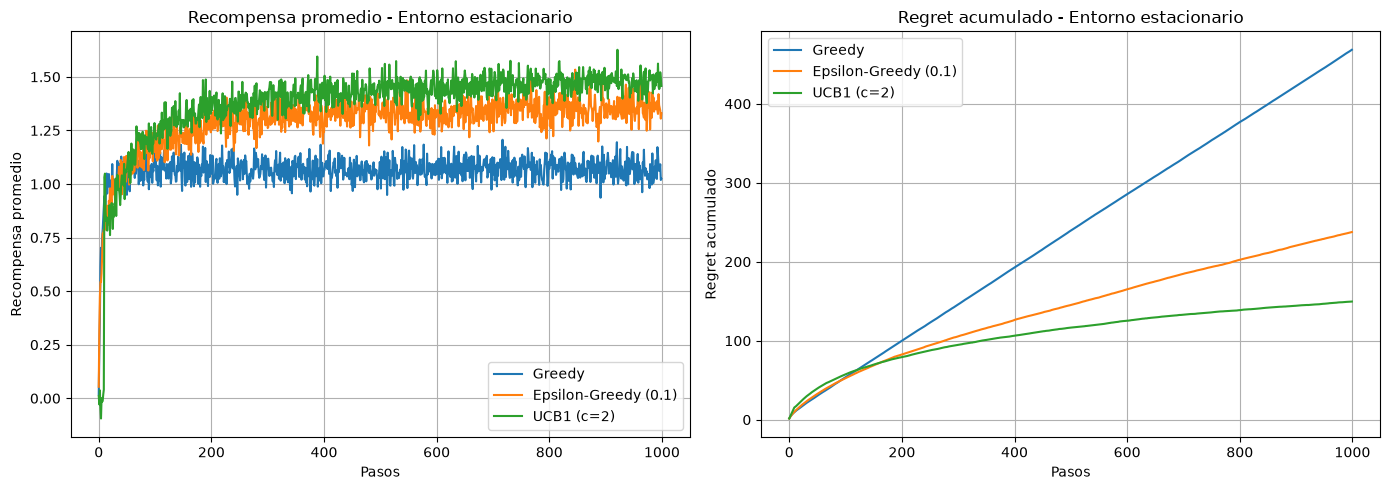

In [3]:
from task2_inciso1.KArmedBandit import *


estrategias = {
    "Greedy": lambda k: EstrategiaGreedy(k),
    "Epsilon-Greedy (0.1)": lambda k: EstrategiaEpsilonGreedy(k, epsilon=0.1),
    "UCB1 (c=2)": lambda k: EstrategiaUCB1(k, c=2),
}

simulador_estacionario = SimuladorBandit(
    k=10,
    num_pasos=1000,
    num_episodios=500,
    estacionario=True,
)
recompensa_est, regret_est = simulador_estacionario.ejecutar(estrategias)
simulador_estacionario.graficar(recompensa_est, regret_est, "Entorno estacionario", "resultados_estacionario")

simulador_no_estacionario = SimuladorBandit(
    k=10,
    num_pasos=1000,
    num_episodios=500,
    estacionario=False,
    intervalo_perturbacion=100,
    sigma_perturbacion=0.01,
)
recompensa_no_est, regret_no_est = simulador_no_estacionario.ejecutar(estrategias)
simulador_no_estacionario.graficar(recompensa_no_est, regret_no_est, "Entorno no estacionario", "resultados_no_estacionario")


### Inciso 2

Con base en los resultados de la implementación:

#### Inciso a

Analicen el comportamiento del regret acumulado de cada estrategia en el entorno estacionario. ¿La jerarquía entre estrategias coincide con lo esperado teóricamente? ¿A partir de qué paso el regret de UCB comienza a diferenciarse del de epsilon-greedy?

**Respuesta:**

#### Inciso b

Analicen qué ocurre en el entorno no estacionario. ¿Qué estrategia se adapta mejor? ¿Cómo cambia el resultado al usar paso constante versus paso variable?

**Respuesta:**


#### Inciso c

Realicen un análisis de sensibilidad: corran epsilon-greedy con al menos tres valores distintos de (\varepsilon) y UCB con al menos tres valores de (c). Grafiquen el regret final en función del hiperparámetro y discutan cuál rango de valores es más robusto.

**Respuesta:**

#### Inciso d

Cierren con una sección de diseño aplicado: tomando los resultados anteriores, ¿qué configuración específica recomendarían para el sistema real que modelaron en la entrega parcial? Justifiquen la recomendación con evidencia de sus experimentos, no solo con argumentos teóricos.

**Respuesta:**